Title: RL_data_analysis.ipynb

Purpose: 

Author: Onno Nennecke on 17.04.2025 Modified: 17.04.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

In [ ]:
path = '/climca/people/onennecke/model_output/winter_data/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files
# After loading the dataset
ts_datasets

<xarray.Dataset> Size: 15MB
Dimensions:        (ESM_run: 99, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    temp           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    sfcWind        (ESM_run, time) float32 721kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds           (ESM_run, time) float32 721kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas            (ESM_run, time) float32 721kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 721kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [3]:
ts_datasets['ESM_run']

<xarray.DataArray 'ESM_run' (ESM_run: 99)> Size: 9kB
array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r5i1p1f1',
       'BCC-CSM2-MR_r1i1p1f1', 'CESM2_r10i1p1f1', 'CESM2_r11i1p1f1',
       'CESM2_r4i1p1f1', 'EC-Earth3_r101i1p1f1', 'EC-Earth3_r102i1p1f1',
       'EC-Earth3_r103i1p1f1', 'EC-Earth3_r104i1p1f1', 'EC-Earth3_r105i1p1f1',
       'EC-Earth3_r106i1p1f1', 'EC-Earth3_r107i1p1f1', 'EC-Earth3_r108i1p1f1',
       'EC-Earth3_r109i1p1f1', 'EC-Earth3_r110i1p1f1', 'EC-Earth3_r111i1p1f1',
       'EC-Earth3_r112i1p1f1', 'EC-Earth3_r113i1p1f1', 'EC-Earth3_r114i1p1f1',
       'EC-Earth3_r115i1p1f1', 'EC-Earth3_r116i1p1f1', 'EC-Earth3_r117i1p1f1',
       'EC-Earth3_r118i1p1f1', 'EC-Earth3_r119i1p1f1', 'EC-Earth3_r120i1p1f1',
       'EC-Earth3_r121i1p1f1', 'EC-Earth3_r122i1p1f1', 'EC-Earth3_r123i1p1f1',
       'EC-Earth3_r124i1p1f1', 'EC-Earth3_r125i1p1f1', 'EC-Earth3_r126i1p1f1',
       'EC-Earth3_r127i1p1f1', 'EC-Earth3_r128i1p1f1', 'EC-Earth3_r129i1p1f1',
       'EC-Earth3_r130i1p1f1', 'EC-Earth3_r131i1p1f1', 'EC-Earth3_r132i1p1f1',
       'EC-Earth3_r133i1p1f1', 'EC-Earth3_r134i1p1f1', 'EC-Earth3_r135i1p1f1',
       'EC-Earth3_r136i1p1f1', 'EC-Earth3_r137i1p1f1', 'EC-Earth3_r138i1p1f1',
       'EC-Earth3_r139i1p1f1', 'EC-Earth3_r140i1p1f1', 'EC-Earth3_r141i1p1f1',
       'EC-Earth3_r142i1p1f1', 'EC-Earth3_r143i1p1f1', 'EC-Earth3_r144i1p1f1',
       'EC-Earth3_r145i1p1f1', 'EC-Earth3_r146i1p1f1', 'EC-Earth3_r147i1p1f1',
       'EC-Earth3_r148i1p1f1', 'EC-Earth3_r149i1p1f1', 'EC-Earth3_r150i1p1f1',
       'EC-Earth3_r1i1p1f1', 'EC-Earth3_r4i1p1f1', 'EC-Earth3_r5i1p1f1',
       'GFDL-ESM4_r1i1p1f1', 'KACE-1-0-G_r1i1p1f1', 'KACE-1-0-G_r2i1p1f1',
       'KACE-1-0-G_r3i1p1f1', 'MPI-ESM1-2-HR_r10i1p1f1',
       'MPI-ESM1-2-HR_r1i1p1f1', 'MPI-ESM1-2-HR_r2i1p1f1',
       'MPI-ESM1-2-HR_r3i1p1f1', 'MPI-ESM1-2-HR_r4i1p1f1',
       'MPI-ESM1-2-HR_r5i1p1f1', 'MPI-ESM1-2-HR_r6i1p1f1',
       'MPI-ESM1-2-HR_r7i1p1f1', 'MPI-ESM1-2-HR_r8i1p1f1',
       'MPI-ESM1-2-HR_r9i1p1f1', 'MRI-ESM2-0_r1i1p1f1', 'MRI-ESM2-0_r2i1p1f1',
       'MRI-ESM2-0_r3i1p1f1', 'MRI-ESM2-0_r4i1p1f1', 'MRI-ESM2-0_r5i1p1f1',
       'TaiESM1_r1i1p1f1', 'UKESM1-0-LL_r10i1p1f2', 'UKESM1-0-LL_r11i1p1f2',
       'UKESM1-0-LL_r12i1p1f2', 'UKESM1-0-LL_r13i1p1f2',
       'UKESM1-0-LL_r14i1p1f2', 'UKESM1-0-LL_r15i1p1f2',
       'UKESM1-0-LL_r16i1p1f2', 'UKESM1-0-LL_r17i1p1f2',
       'UKESM1-0-LL_r18i1p1f2', 'UKESM1-0-LL_r19i1p1f2',
       'UKESM1-0-LL_r1i1p1f2', 'UKESM1-0-LL_r2i1p1f2', 'UKESM1-0-LL_r3i1p1f2',
       'UKESM1-0-LL_r4i1p1f2', 'UKESM1-0-LL_r5i1p1f2', 'UKESM1-0-LL_r6i1p1f2',
       'UKESM1-0-LL_r7i1p1f2', 'UKESM1-0-LL_r8i1p1f2', 'UKESM1-0-LL_r9i1p1f2'],
      dtype='<U23')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...

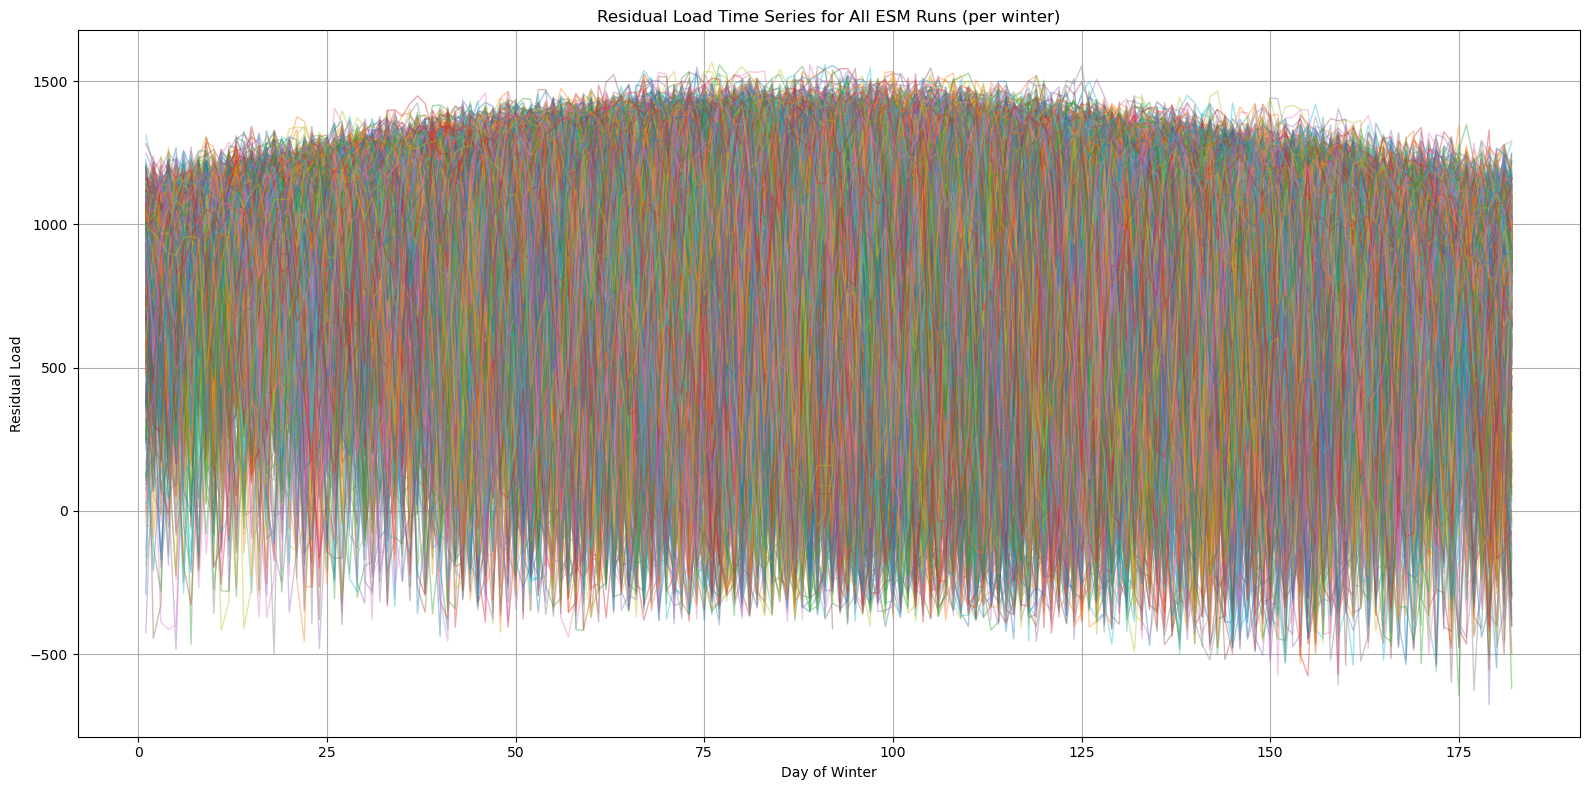

In [4]:
residual = ts_datasets['Residual_load'].compute()
day_of_winter = ts_datasets['day_of_winter'].values
winter_years = ts_datasets['winter_year'].values
esm_runs = ts_datasets['ESM_run'].values

plt.figure(figsize=(16, 8))

for i in range(residual.shape[0]):
    for year in np.unique(winter_years):
        mask = winter_years == year
        plt.plot(day_of_winter[mask], residual[i, mask], alpha=0.4, linewidth=1)

plt.title('Residual Load Time Series for All ESM Runs (per winter)')
plt.xlabel('Day of Winter')
plt.ylabel('Residual Load')
plt.grid(True)
plt.tight_layout()
plt.show()
